## Importing libraries

In [17]:
import re
import math
import random
from collections import Counter, defaultdict
from typing import List, Tuple, Dict, Optional
import pandas as pd
import matplotlib.pyplot as plt

 ## DATA LOADING + TOKENIZATION

In [18]:
def load_text(path: str, encoding="utf-8") -> str:
    with open(path, "r", encoding=encoding) as f:
        return f.read()

def tokenize(
    text: str,
    lowercase: bool = True,
    keep_punct_as_tokens: bool = True
) -> List[str]:
    """
    Tokenizer options:
    - lowercase: convert to lowercase
    - keep_punct_as_tokens: keep punctuation .,!?;: as separate tokens
    """
    if lowercase:
        text = text.lower()

    if keep_punct_as_tokens:
        # Words (including apostrophes) OR single punctuation tokens
        tokens = re.findall(r"[a-zA-ZÀ-ž0-9']+|[.,!?;:()\"-]", text)
    else:
        # Keep only word-like tokens
        tokens = re.findall(r"[a-zA-ZÀ-ž0-9']+", text)

    return tokens

def train_test_split(tokens: List[str], test_ratio: float = 0.1) -> Tuple[List[str], List[str]]:
    cut = int(len(tokens) * (1 - test_ratio))
    return tokens[:cut], tokens[cut:]

In [19]:
def make_ngrams(tokens: List[str], n: int) -> List[Tuple[str, ...]]:
    return [tuple(tokens[i:i+n]) for i in range(len(tokens) - n + 1)]

##  N-GRAM COUNT MODELS

In [20]:
class NGramLM:
    """
    Supports unigram, bigram, trigram training.
    Provides:
    - frequency counts
    - conditional probabilities with Laplace smoothing
    - bigram autocomplete
    - trigram text generation
    - perplexity evaluation
    """
    def __init__(self, n: int, laplace_k: float = 1.0):
        assert n in (1, 2, 3), "This simple implementation supports n = 1, 2, 3."
        self.n = n
        self.k = laplace_k

        self.ngram_counts: Counter = Counter()
        self.context_counts: Counter = Counter()  # counts of (n-1)-gram contexts
        self.vocab: set = set()
        self.vocab_size: int = 0

        # For sampling generation (context -> list of (word, count))
        self.next_word_counts: Dict[Tuple[str, ...], Counter] = defaultdict(Counter)

    def fit(self, tokens: List[str]) -> None:
        self.vocab = set(tokens)
        self.vocab_size = len(self.vocab)

        ngrams = make_ngrams(tokens, self.n)
        self.ngram_counts = Counter(ngrams)

        if self.n == 1:
            # For unigrams, "context" is empty tuple
            self.context_counts = Counter({(): sum(self.ngram_counts.values())})
            for (w,), c in self.ngram_counts.items():
                self.next_word_counts[()][w] += c
        else:
            contexts = [ng[:-1] for ng in ngrams]
            self.context_counts = Counter(contexts)
            for ng, c in self.ngram_counts.items():
                ctx, w = ng[:-1], ng[-1]
                self.next_word_counts[ctx][w] += c

    def most_frequent(self, top_k: int = 20) -> List[Tuple[Tuple[str, ...], int]]:
        return self.ngram_counts.most_common(top_k)

    
    # PROBABILITIES (with Laplace smoothing)
    def prob(self, word: str, context: Optional[Tuple[str, ...]] = None) -> float:
        """
        Returns P(word | context) with Laplace smoothing (add-k).
        For unigram, context is ignored or should be ().
        """
        if self.n == 1:
            context = ()
            count_wc = self.ngram_counts.get((word,), 0)
            count_c = self.context_counts.get((), 0)
        else:
            assert context is not None and len(context) == self.n - 1
            count_wc = self.ngram_counts.get(tuple(context) + (word,), 0)
            count_c = self.context_counts.get(context, 0)

        # Laplace smoothing:
        # P = (count(context,word) + k) / (count(context) + k*|V|)
        return (count_wc + self.k) / (count_c + self.k * self.vocab_size)

    def next_word_distribution(self, context: Tuple[str, ...], top_k: int = 10) -> List[Tuple[str, float]]:
        """
        Returns top_k next-word predictions with probabilities.
        """
        # If context unseen, all words become equal under Laplace smoothing
        candidates = []
        for w in self.vocab:
            candidates.append((w, self.prob(w, context)))
        candidates.sort(key=lambda x: x[1], reverse=True)
        return candidates[:top_k]

     # ----------------------------
    # 4) BIGRAM AUTOCOMPLETE
    # ----------------------------

    def autocomplete(self, word: str, top_k: int = 5) -> List[Tuple[str, float]]:
        """
        Only meaningful for bigrams:
        suggest most probable next words given one word.
        """
        if self.n != 2:
            raise ValueError("Autocomplete is intended for a bigram model (n=2).")

        context = (word,)
        return self.next_word_distribution(context, top_k=top_k)

     # ----------------------------
    # 5) TRIGRAM TEXT GENERATION
    # ----------------------------

    def _sample_next(self, context: Tuple[str, ...]) -> str:
        """
        Sample a next word from P(word|context).
        Uses Laplace-smoothed distribution over vocabulary.
        """
        words = list(self.vocab)
        probs = [self.prob(w, context) for w in words]

        # random.choices uses weights (not necessarily normalized)
        return random.choices(words, weights=probs, k=1)[0]

    def generate(self, seed: List[str], num_words: int = 50, stop_tokens: set = None) -> str:
        """
        Generate text continuing from 'seed'.
        For trigram model (n=3): needs 2 tokens context; we will use last 2.
        """
        if stop_tokens is None:
            stop_tokens = {".", "!", "?"}

        out = seed[:]
        if self.n == 1:
            # unigram generation ignores context
            for _ in range(num_words):
                out.append(self._sample_next(()))
            return " ".join(out)

        if len(out) < self.n - 1:
            raise ValueError(f"Seed must have at least {self.n - 1} tokens for n={self.n}.")

        for _ in range(num_words):
            context = tuple(out[-(self.n - 1):])
            nxt = self._sample_next(context)
            out.append(nxt)

        # Simple spacing fix for punctuation if you kept it as tokens
        text = " ".join(out)
        text = re.sub(r"\s+([.,!?;:])", r"\1", text)
        return text

    # 6) PERPLEXITY EVALUATION
    # ----------------------------

    def perplexity(self, tokens: List[str]) -> float:
        """
        Perplexity = exp( - (1/N) * sum log P(w_i | context_i) )
        Uses Laplace-smoothed probabilities to avoid zero probabilities.
        """
        if len(tokens) < self.n:
            raise ValueError("Not enough tokens to compute perplexity for this n.")

        ngrams = make_ngrams(tokens, self.n)
        log_prob_sum = 0.0
        N = len(ngrams)

        for ng in ngrams:
            if self.n == 1:
                ctx = ()
                w = ng[0]
            else:
                ctx = ng[:-1]
                w = ng[-1]

            p = self.prob(w, ctx if self.n > 1 else ())
            log_prob_sum += math.log(p)

        return math.exp(-log_prob_sum / N)

In [21]:
def predict(word,model):
    preds = model.autocomplete(word, top_k=5)
    return pd.DataFrame(preds, columns=["Word", "Probability"])

## PROBABILITIES (with Laplace smoothing)

Loaded tokens: 1,271,806
Unique tokens: 33,980
Train tokens:  1,144,625
Test tokens:   127,181

Total tokens: 1271806
Vocabulary size: 33980
First 20 tokens:  ['pm', 'denies', 'knowledge', 'of', 'awb', 'kickbacks', 'the', 'prime', 'minister', 'has', 'denied', 'he', 'knew', 'awb', 'was', 'paying', 'kickbacks', 'to', 'iraq', 'despite']

=== Most frequent unigrams ===
    Unigram  Count
0    (the,)  68136
1      (,,)  49853
2      (.,)  43725
3     (of,)  32253
4     (to,)  30582
5    (and,)  24643
6     (in,)  21662
7      (a,)  20500
8     (is,)  14148
9      (",)  13907
10  (that,)  13196
11   (for,)  10121
12     (-,)   8356
13    (it,)   7920
14    (be,)   7694


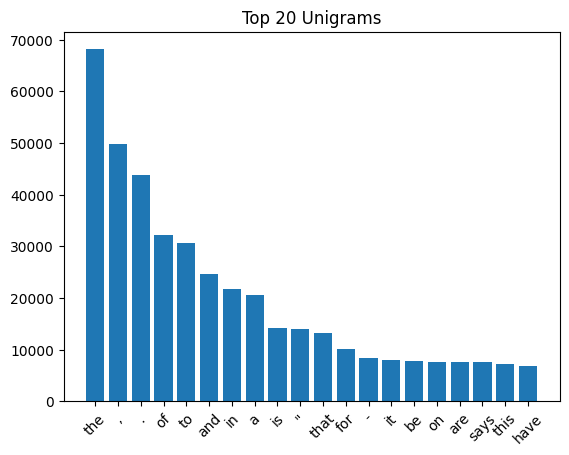


=== Most frequent bigrams ===
        Bigram  Count
0    (of, the)   8696
1       (., ")   7828
2    (in, the)   6233
3     (., the)   5212
4       (,, ")   4326
5     (,, the)   3054
6    (to, the)   2993
7     (,, and)   2502
8    (on, the)   2431
9      (", he)   2271
10    (to, be)   2171
11    (it, is)   2157
12   (said, .)   1995
13  (for, the)   1993
14  (,, which)   1969

=== Most frequent trigrams ===

=== Bigram next-word probabilities after 'the' (Laplace smoothed) ===
P(commission | the) = 0.016112
P(european | the) = 0.012257
P(first | the) = 0.006820
P(same | the) = 0.005970
P(new | the) = 0.005842

=== Autocomplete tests ===
Input: 'the' -> [('commission', 0.016111814012335916), ('european', 0.012256840107543887), ('first', 0.0068203384469397435), ('same', 0.005970267278190732), ('new', 0.005841768148030998)]
Input: 'the' -> [('commission', 0.016111814012335916), ('european', 0.012256840107543887), ('first', 0.0068203384469397435), ('same', 0.005970267278190732), ('new'

In [31]:
def run_demo(
    file_path: str,
    lowercase: bool = True,
    keep_punct_as_tokens: bool = True,
    test_ratio: float = 0.1,
    top_k: int = 15
):
    raw = load_text(file_path)
    tokens = tokenize(raw, lowercase=lowercase, keep_punct_as_tokens=keep_punct_as_tokens)

    print(f"Loaded tokens: {len(tokens):,}")
    print(f"Unique tokens: {len(set(tokens)):,}")
    train_tokens, test_tokens = train_test_split(tokens, test_ratio=test_ratio)
    print(f"Train tokens:  {len(train_tokens):,}")
    print(f"Test tokens:   {len(test_tokens):,}\n")

    print("Total tokens:", len(tokens))
    print("Vocabulary size:", len(set(tokens)))
    print(f"First 20 tokens:  {tokens[:20]}\n")

    # 1) Frequencies: unigram, bigram, trigram
    uni = NGramLM(n=1, laplace_k=1.0)
    bi  = NGramLM(n=2, laplace_k=1.0)
    tri = NGramLM(n=3, laplace_k=1.0)

    uni.fit(train_tokens)
    bi.fit(train_tokens)
    tri.fit(train_tokens)

    print("=== Most frequent unigrams ===")
    uniPD = pd.DataFrame(uni.most_frequent(top_k), columns=["Unigram", "Count"])
    # for ng, c in uni.most_frequent(top_k):
    #     print(f"{ng} -> {c}")
    print(uniPD)

    words, counts = zip(*[(w[0], c) for w, c in uni.most_frequent(20)])
    plt.figure()
    plt.bar(words, counts)
    plt.xticks(rotation=45)
    plt.title("Top 20 Unigrams")
    plt.show()
    print()

    print("=== Most frequent bigrams ===")
    # for ng, c in bi.most_frequent(top_k):
    #     print(f"{ng} -> {c}")
    biPD = pd.DataFrame(bi.most_frequent(top_k), columns=["Bigram", "Count"])
    print(biPD)
    # words, counts = zip(*[(w[0], c) for w, c in bi.most_frequent(20)])
    # plt.figure()
    # plt.bar(words, counts)
    # plt.xticks(rotation=45)
    # plt.title("Top 20 Bigrams")
    # plt.show()
    print()

    print("=== Most frequent trigrams ===")
    # for ng, c in tri.most_frequent(top_k):
    #     print(f"{ng} -> {c}")
    triPD = pd.DataFrame(tri.most_frequent(top_k), columns=["Trigram", "Count"])
    # words, counts = zip(*[(w[0], c) for w, c in bi.most_frequent(20)])
    # plt.figure()
    # plt.bar(words, counts)
    # plt.xticks(rotation=45)
    # plt.title("Top 20 Bigrams")
    # plt.show()
    # print()
    print()

    # 2) Probability examples with Laplace smoothing
    example_context = None
    if bi.n == 2:
        # pick a common word from training data
        common_word = uni.most_frequent(1)[0][0][0]
        example_context = (common_word,)
        preds = bi.autocomplete(common_word, top_k=5)
        print(f"=== Bigram next-word probabilities after '{common_word}' (Laplace smoothed) ===")
        for w, p in preds:
            print(f"P({w} | {common_word}) = {p:.6f}")
        print()

    # 3) Autocomplete testing
    if example_context:
        print("=== Autocomplete tests ===")
        for test_word in [example_context[0], "the", "and", "i"]:
            if test_word in bi.vocab:
                preds = bi.autocomplete(test_word, top_k=5)
                print(f"Input: '{test_word}' -> {preds}")
        print()

    # 4) Trigram text generation
    print("=== Trigram generation ===")
    # seed: take two tokens from train
    seed = train_tokens[:2]
    print("Seed:", seed)
    gen = tri.generate(seed=seed, num_words=60)
    print(gen)
    print()

    # 5) Perplexity comparison on test set
    print("=== Perplexity on test set (lower is better) ===")
    ppl_uni = uni.perplexity(test_tokens)
    ppl_bi  = bi.perplexity(test_tokens)
    ppl_tri = tri.perplexity(test_tokens)

    print(f"Unigram perplexity: {ppl_uni:.3f}")
    print(f"Bigram  perplexity: {ppl_bi:.3f}")
    print(f"Trigram perplexity: {ppl_tri:.3f}")

    print()
    print('predict', predict('the',bi))


if __name__ == "__main__":
    # Example usage:
    # run_demo("./datasets/english.txt")
    # run_demo("./datasets/rural.txt")
    run_demo("./datasets/science.txt")
    pass